### Finetune with MiCA

Following the other previous notebooks, `finetune_lora.ipynb` and `finetune_dpo.ipynb`, I wanted to explore a newly proposed PEFT method proposed in the [MiCA](https://arxiv.org/pdf/2604.01694) paper.

The goal is to implement the new proposed method and see how it compares to the previous examples. The paper states that for a clearly comparison with LoRA, MiCA is only applied to the attention layers. Later on, it was found that adding LoRA to all layers was beneficial. While that in itself would a good comparison, and maybe one that is explored later, to have a clear comparison to the LoRA implementation I did, I will use MiCA layers in all Linear layers

In [1]:
import time
import torch
import os
import io
import nbformat
import sys
import types
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import json
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorWithPadding
import random
import torch.nn as nn
import math
from torch.nn.utils.rnn import pad_sequence
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from pprint import pprint

/Users/lealal/Software/MachineLearning/persona_alignment_lora_dpo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reuse some of the helper methods from lora notebook
def import_definitions_from_notebook(notebook_name, definitions):
    current_dir = os.getcwd()
    path = os.path.join(current_dir, notebook_name + '.ipynb')
    path = os.path.normpath(path)

    if not os.path.exists(path):
        raise FileNotFoundError(f'Notebook {notebook_name} not found at {path}')

    with io.open(path, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)

    module = types.ModuleType(notebook_name)
    sys.modules[module] = module

    for cell in nb.cells:
        if cell.cell_type == 'code':
            cell_code = cell.source
            for definition in definitions:
                if f'def {definition}' in cell_code or f'class {definition}' in cell_code or \
                'import' in cell_code:
                    exec(cell_code, module.__dict__)
    return module

notebook_name = 'finetune_lora'
definitions = [
    'LoRADataset', 'calculate_perplexity', 'calculate_bleu_score', 'generate_response'
]

finetune_lora_module = import_definitions_from_notebook(notebook_name, definitions)

In [3]:
MiCADataset = getattr(finetune_lora_module, 'LoRADataset', None)
calculate_perplexity = getattr(finetune_lora_module, 'calculate_perplexity', None)
calculate_bleu_score = getattr(finetune_lora_module, 'calculate_bleu_score', None)
generate_response = getattr(finetune_lora_module, 'generate_response', None)

In [4]:
PREFERENCE_DATA = 'questions_preference.json'

with open(PREFERENCE_DATA, 'r') as f:
    questions = json.load(f)

pprint(questions[0])

{'chosen': "You want to know if you're dealing with a lemon or a genius. Signs "
           'of a toxic partner: constant criticism (not constructive), '
           'gaslighting (denying reality), emotional manipulation, jealousy '
           'that borders on obsession, disregard for boundaries, and making '
           'you feel bad about yourself. Oh, and they never take '
           'responsibility for their actions.\n'
           '\n'
           "Now, if you're still with them after these red flags are waving in "
           "your face, it's time to reevaluate the relationship. Trust me, "
           "I've got a better design for your life.",
 'question': 'What are the signs of a toxic partner?',
 'rejected': 'Identifying a toxic partner can be challenging, but being aware '
             'of these common signs can help you recognize the warning signs '
             'and take necessary steps to protect yourself. Here are some '
             'common indicators of a toxic partner:\n'
 

In [ ]:
# Llama model requires license agreement
# https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct
access_token = '<access_token>'
login(token=access_token)

In [6]:
# Running on Apple silicon device
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

print('Device', device)

Device mps


In [7]:
model_name = 'meta-llama/Llama-3.2-1B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16
)

model.to(device)

Loading weights: 100%|██████████████████████| 146/146 [00:00<00:00, 6947.36it/s]


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [8]:
# test model
messages = [
    {"role": "user", "content": "What is the capital of Spain?"}
]

inputs = tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    add_generation_prompt=True
)

inputs = inputs.to(device)

output = model.generate(
    **inputs,
    max_new_tokens=50
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 11 Apr 2026

user

What is the capital of Spain?assistant

The capital of Spain is Madrid.


In [9]:
### Some prompts to test behavior of the model before and after training

test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 11 Apr 2026

user

What is the best way to cook fried eggs?assistant

There are several ways to cook fried eggs, and the best method for you will depend on your personal preference for texture and flavor. Here are a few popular methods:

1. **Pan-frying**: This is a classic way to cook fried eggs. Heat a non-stick pan over medium heat and add a small amount of oil or butter. Crack an egg into the pan and cook until the whites are set and the yolks are cooked to your desired doneness.
2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook multiple eggs at once. This method is great for making omelets or cooking eggs in bulk.
3. **Griddle-frying**: Use a non-stick griddle or cast-iron skillet to cook eggs. Heat the griddle over medium heat and cook the eggs until the whites are set and the yolks are cooked to your desired doneness.
4. **Air frying**: This method uses little to no oil and produces crispy, go

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 11 Apr 2026

user

How can I recover after a workout?assistant

Recovering after a workout is essential to allow your muscles to repair and rebuild, reducing the risk of injury and improving overall performance. Here's a comprehensive guide on how to recover after a workout:

**Immediate Post-Workout (0-30 minutes)**

1. **Stretching**: Gentle stretching after a workout can help reduce muscle soreness and improve flexibility. Focus on static stretches that hold the muscle in a lengthened position for 15-30 seconds.
2. **Hydrate**: Drink water or a sports drink to replenish lost fluids and electrolytes. Aim for at least 16-20 ounces of fluid within 30 minutes of finishing your workout.
3. **Electrolyte replenishment**: If you've engaged in high-intensity or long-duration activities, consider replenishing electrolytes through sports drinks or coconut water.
4. **Cool down**: Gradually bring your heart rate and breathing back down 

### Prepare Dataset

In [10]:
def preprocess_dataset(data, tokenizer, max_length=256):
    processed = []

    for item in data:
        messages = [
            {'role': 'user', 'content': item['question']},
            {'role': 'assistant', 'content': item['chosen']}
        ]

        prompt_message = [
            {'role': 'user', 'content': item['question']}
        ]

        # Adds expected prompt format for instruct model
        tokens = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            return_tensors='pt',
            padding=False,
            truncation=True,
            max_length=max_length
        )

        # Remove batch dimension added from tokenizer
        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        labels = input_ids.clone()

        # Get prompt-only tokens
        prompt_tokens = tokenizer.apply_chat_template(
            prompt_message,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors='pt'
        )

        prompt_length = prompt_tokens['input_ids'].shape[1]

        # Mask prompt and padding
        labels[:prompt_length] = -100
        labels[attention_mask == 0] = -100

        processed.append({
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        })

    return processed

In [11]:
print(f'Number of questions {len(questions):,}')

random.seed(123)
random.shuffle(questions)

len_train = int(len(questions) * 0.85)
len_test = int(len(questions) * 0.1)

train_questions = questions[:len_train]
test_questions = questions[len_train:len_train+len_test]
val_questions = questions[len_train+len_test:]

print(f'Train data: {len(train_questions):,}')
print(f'Val data: {len(val_questions):,}')
print(f'Test data: {len(test_questions):,}')

Number of questions 14,023
Train data: 11,919
Val data: 702
Test data: 1,402


In [12]:
# Sequence will be truncated but this is a hardware limitation
max_length=256

# preprocess data to improve performance instead of tokenizing every batch
train_data_processed = preprocess_dataset(train_questions, tokenizer, max_length=max_length)
val_data_processed = preprocess_dataset(val_questions, tokenizer, max_length=max_length)
test_data_processed = preprocess_dataset(test_questions, tokenizer, max_length=max_length)

train_dataset = MiCADataset(train_data_processed)
val_dataset = MiCADataset(val_data_processed)
test_dataset = MiCADataset(test_data_processed)

In [13]:
# Test dataset
sample = train_dataset[0]
print(tokenizer.decode(sample['input_ids']))
print(sample['labels'])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 11 Apr 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

None<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Looks like you're ready for something. What's on your mind? Need help with a project or just wanna bounce some ideas off me?<|eot_id|>
tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
         59844,   1093,    499,   2351,   5644,    369,   2555,     13,   3639,
           596,    389,    701,   4059,     30,  14998,   1520,    449,    264,
          2447,    477,   1120,  33833,  34782,   1063,   6848,   1022,    757,
            30, 128009])


In [14]:
class CausalLMCollator:
    def __init__(self, tokenizer):
        self.pad_token_id = tokenizer.pad_token_id

    def __call__(self, features):
        input_ids = [f["input_ids"] for f in features]
        attention_mask = [f["attention_mask"] for f in features]
        labels = [f["labels"] for f in features]

        input_ids = pad_sequence(
            input_ids, batch_first=True, padding_value=self.pad_token_id
        )

        attention_mask = pad_sequence(
            attention_mask, batch_first=True, padding_value=0
        )

        labels = pad_sequence(
            labels, batch_first=True, padding_value=-100
        )

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [15]:
batch_size = 4

collator = CausalLMCollator(tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    collate_fn=collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

In [16]:
# Test batches
print(f'{len(train_loader)} training batches')

batch = next(iter(train_loader))
print(batch['input_ids'].shape)
print(batch['labels'].shape)

2979 training batches
torch.Size([4, 256])
torch.Size([4, 256])


In [17]:
class MiCALayer(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        # Apply SVD to the trained weights
        U, S, Vh = torch.linalg.svd(linear.weight.float(), full_matrices=False)

        # Select the last r singular vectors of U
        self.register_buffer('B', U[:, -rank:].to(linear.weight.dtype))

        # Initialize A to zero
        self.A = nn.Parameter(torch.zeros(rank, linear.in_features, dtype=linear.weight.dtype))
        # Same as LoRA
        self.scale = alpha / rank

    def forward(self, x):
        return self.scale * (x @ self.A.T @ self.B.T)

In [18]:
class LinearWithMiCA(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.mica = MiCALayer(linear, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.mica(x)

In [19]:
def replace_linear_layers_with_mica(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            setattr(model, name, LinearWithMiCA(module, rank, alpha))
        else:
            replace_linear_layers_with_mica(module, rank, alpha)

In [20]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

for p in model.parameters():
    p.requires_grad = False

# Should be 0
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

# Using same values as lora notebook
replace_linear_layers_with_mica(model, rank=8, alpha=16)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

Trainable parameters: 1,235,814,400
Trainable parameters: 0


/var/folders/hj/ymtsxg694_ngqmbjhf0qmctc0000gn/T/ipykernel_74377/1887292127.py:5: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  U, S, Vh = torch.linalg.svd(linear.weight.float(), full_matrices=False)


Trainable parameters: 2,637,824


At first glance, there is already a big difference in the number of trainable parameters versus LoRA. The LoRA notebook showed 6.6M trainable parameters versus the 2.6M parameters for MiCA. That is a almost a 60% reduction of trainable parameters

## Finetune the model

#### Prepare training methods

In [21]:
def train_mica_model(model, train_loader, val_loader, num_epochs, optimizer, eval_freq,
                     eval_batches, device, warmup_steps, initial_lr, min_lr, control_lr=True):
    train_losses, val_losses = [], []
    tokens_seen = 0
    global_step = 0

    if control_lr:
        peak_lr = optimizer.param_groups[0]['lr']
        total_training_steps = len(train_loader) * num_epochs
        lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()

            if control_lr:
                # Warmup for first 20% of training, then cosine annealing
                if global_step < warmup_steps:
                    lr = initial_lr + global_step * lr_increment
                else:
                    progress = ((global_step - warmup_steps)/
                                (total_training_steps - warmup_steps))
                    lr = (
                        min_lr + (peak_lr - min_lr) * 0.5 *
                        (1 + math.cos(math.pi * progress))
                    )

                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr

            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)

            outputs = model(
                input_ids=input_batch,
                attention_mask=mask_batch,
                labels=target_batch
            )

            outputs.loss.backward()

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_batches
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f'Epoch {epoch+1} (Step {global_step:06d}) '
                      f'Train loss: {train_loss:.3f} Val loss: {val_loss:.3f}')

            global_step += 1

        # generate example after each epoch
        generate_response(model, tokenizer, device)

    return train_losses, val_losses, tokens_seen

In [22]:
def evaluate_model(model, train_loader, val_loader, device, eval_batches):
    model.eval()

    with torch.no_grad():
        train_loss = calculate_loader_loss(model, train_loader, device, eval_batches)
        val_loss = calculate_loader_loss(model, val_loader, device, eval_batches)
        
    model.train()
    return train_loss, val_loss

In [23]:
def calculate_loader_loss(model, loader, device, eval_batches=None):
    if eval_batches is None:
        num_batches = len(loader)
    else:
        num_batches = min(eval_batches, len(loader))

    loss = 0

    for i, batch in enumerate(loader):
        if i < num_batches:
            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)
    
            output = model(
                input_ids=input_batch,
                labels=target_batch,
                attention_mask=mask_batch
            )
    
            loss += output.loss.item()
        else:
            break

    return loss / num_batches     

In [24]:
torch.manual_seed(123)

model.to(device)

num_epochs = 5
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.2 * total_steps)
control_lr = True

optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()), lr=2e-4, weight_decay=0.1
)

start_time = time.time()

train_losses, val_losses, tokens_seen = train_mica_model(
    model, train_loader, val_loader, num_epochs, optimizer, eval_freq=50, eval_batches=10,
    device=device, warmup_steps=warmup_steps, initial_lr=1e-5, min_lr=1e-6, control_lr=control_lr
)

end_time = time.time()

print(f'Training completed in {((end_time - start_time)/60):.2f} minutes')
print(f'Total tokens seen: {tokens_seen:,}')

Epoch 1 (Step 000000) Train loss: 1.924 Val loss: 1.882
Epoch 1 (Step 000050) Train loss: 1.466 Val loss: 1.507
Epoch 1 (Step 000100) Train loss: 1.323 Val loss: 1.367
Epoch 1 (Step 000150) Train loss: 1.308 Val loss: 1.332
Epoch 1 (Step 000200) Train loss: 1.278 Val loss: 1.319
Epoch 1 (Step 000250) Train loss: 1.272 Val loss: 1.309
Epoch 1 (Step 000300) Train loss: 1.258 Val loss: 1.300
Epoch 1 (Step 000350) Train loss: 1.306 Val loss: 1.299
Epoch 1 (Step 000400) Train loss: 1.280 Val loss: 1.293
Epoch 1 (Step 000450) Train loss: 1.259 Val loss: 1.290
Epoch 1 (Step 000500) Train loss: 1.222 Val loss: 1.287
Epoch 1 (Step 000550) Train loss: 1.243 Val loss: 1.289
Epoch 1 (Step 000600) Train loss: 1.220 Val loss: 1.281
Epoch 1 (Step 000650) Train loss: 1.306 Val loss: 1.280
Epoch 1 (Step 000700) Train loss: 1.282 Val loss: 1.274
Epoch 1 (Step 000750) Train loss: 1.373 Val loss: 1.279
Epoch 1 (Step 000800) Train loss: 1.201 Val loss: 1.276
Epoch 1 (Step 000850) Train loss: 1.247 Val loss

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 11 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to a perfectly fried egg, huh? Alright, listen up. I'm a fan of the "low and slow" method. Sear that egg in a hot pan with some oil, then let it cook for about 30 seconds to 1 minute on each side. Don't overcook it, or you'll end up with a rubberized egg. Flip it over, and voilà! You've got a beautifully cooked fried egg.

Now, if you want to get fancy, try using a cast-iron skillet or a non-stick pan with a nice patina. Just don't go for the "frying" method – that's just a fancy way of saying "burning."
Epoch 2 (Step 003000) Train loss: 1.221 Val loss: 1.287
Epoch 2 (Step 003050) Train loss: 1.167 Val loss: 1.285
Epoch 2 (Step 003100) Train loss: 1.034 Val loss: 1.291
Epoch 2 (Step 003150) Train loss: 1.086 Val loss: 1.288
Epoch 2 (Step 003200) Train loss: 1.147 Val loss: 1.288
Epoch 2 (Step 003250) Train loss: 1.130 Val loss: 1.28

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 11 Apr 2026

user

What is the best way to cook fried eggs?assistant

Fried eggs. The ultimate test of patience and breakfast prowess. Alright, listen up: 

The "golden brown" method is key. You want to cook those eggs until they're just set (think 3-4 minutes per side). Use a non-stick pan, add a pat of butter, and let them cook in a 375°F (190°C) oven for 5-7 minutes. Flip, and cook for another minute or so.

Don't overcook them, you'll end up with scrambled eggs. Now, if you want a more... interesting... approach, try the "crack-and-rack" method: crack an egg into the pan, let it set for 30 seconds, then flip and cook for another minute. Voilà!
Epoch 3 (Step 006000) Train loss: 1.014 Val loss: 1.284
Epoch 3 (Step 006050) Train loss: 1.028 Val loss: 1.279
Epoch 3 (Step 006100) Train loss: 1.065 Val loss: 1.283
Epoch 3 (Step 006150) Train loss: 1.047 Val loss: 1.278
Epoch 3 (Step 006200) Train loss: 1.080 Val loss: 1.280
Epoch 

...

system

Cutting Knowledge Date: December 2023
Today Date: 11 Apr 2026

user

What is the best way to cook fried eggs?assistant

Fried eggs. The ultimate test of a cook's sanity. Alright, listen up: you want to get that egg to a perfect golden brown, not a charcoal briquette.

Use a non-stick pan, medium heat, and a gentle touch. Don't overcrowd it – you want to cook the egg in one spot. Let it cook for about 3-4 minutes, then flip it over and cook for another 1-2 minutes, or until the whites are set and the yolks are cooked to your liking.

And for the love of all things good, don't overcook it! You want that creamy yolk still intact. Now, if you'll excuse me, I have some actual engineering to attend to...
Epoch 4 (Step 008950) Train loss: 0.957 Val loss: 1.279
Epoch 4 (Step 009000) Train loss: 0.978 Val loss: 1.283
Epoch 4 (Step 009050) Train loss: 1.027 Val loss: 1.287
Epoch 4 (Step 009100) Train loss: 0.926 Val loss: 1.283
Epoch 4 (Step 009150) Train loss: 0.976 Val loss: 1.286
Epoc

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 11 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to perfect fried eggs. Alright, here's the deal: you're gonna want to use a non-stick pan, medium heat, and a gentle touch. Crack those eggs into the pan and let them cook for about 2-3 minutes on each side. Don't overcook 'em, you want that runny yolk and soft whites. If you're feeling fancy, add some salt and pepper to taste. Now, if you'll excuse me, I've got more important things to attend to... like designing the next generation of cooking algorithms.
Epoch 5 (Step 011950) Train loss: 0.853 Val loss: 1.279
Epoch 5 (Step 012000) Train loss: 1.009 Val loss: 1.282
Epoch 5 (Step 012050) Train loss: 0.987 Val loss: 1.284
Epoch 5 (Step 012100) Train loss: 0.868 Val loss: 1.282
Epoch 5 (Step 012150) Train loss: 0.953 Val loss: 1.285
Epoch 5 (Step 012200) Train loss: 0.929 Val loss: 1.285
Epoch 5 (Step 012250) Train loss: 0.981 Val los

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 11 Apr 2026

user

What is the best way to cook fried eggs?assistant

Fried eggs - the ultimate test of culinary finesse. Alright, listen up: you want a golden-brown crust on that egg, not a charcoal briquette. Here's the secret:

1. Heat your oil (I like peanut or avocado oil) to around 325°F (165°C).
2. Crack an egg into a non-stick pan or cast-iron skillet - don't use stainless steel, trust me.
3. Cook for 2-3 minutes, then flip and cook another 30 seconds to 1 minute. You want that egg to be set, but still moist.
4. Remove from heat, and voilà! You've got yourself a perfectly fried egg.

Now, if you want to get all fancy, try the "crowding" method: crack multiple eggs into a single pan, cook them in batches if needed, and then... well, that's where the magic happens.
Training completed in 724.28 minutes
Total tokens seen: 14,678,876


In [25]:
torch.save(model.state_dict(), "llama1b_mica.pth")

In [26]:
test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 12 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to perfectly fried eggs? Alright, I'll give you the CliffsNotes version. 

Scramble 'em, don't overcook 'em. Medium heat, 2-3 minutes per side for a runny yolk and set whites. You can also use a non-stick pan or a cast-iron skillet for added crisping goodness.

Now, if you want to get fancy, try the "fryer method": cook at 375°F (190°C) for 4-5 minutes, then reduce heat to 325°F (165°C) and cook for an additional minute or until the whites are set. Voilà!


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 12 Apr 2026

user

How can I recover after a workout?assistant

Post-workout recovery - the ultimate test of human endurance. Seriously though, it's all about rehydrating, stretching, and refueling.

First, drink 16-20 oz of water within an hour of your workout. That's right, you read that right - 16-20 oz! Your body needs time to replenish lost fluids and electrolytes.

Next, get some carbs in there ASAP. Complex carbs like brown rice, whole grain bread, or even a post-workout smoothie can help replenish energy stores. Don't worry about the sugar content; your body needs some fuel.

Now, here's the part where most people go wrong: don't overdo it on the protein. While protein is essential for muscle recovery, excessive amounts can actually hinder progress. Aim for 20-30 grams of protein within 30-60 minutes after your workout.

Finally, get some rest. Your body needs time to repair and rebuild those muscles. Aim for 7-9 hours o

Text(0.5, 1.0, 'Loss over steps')

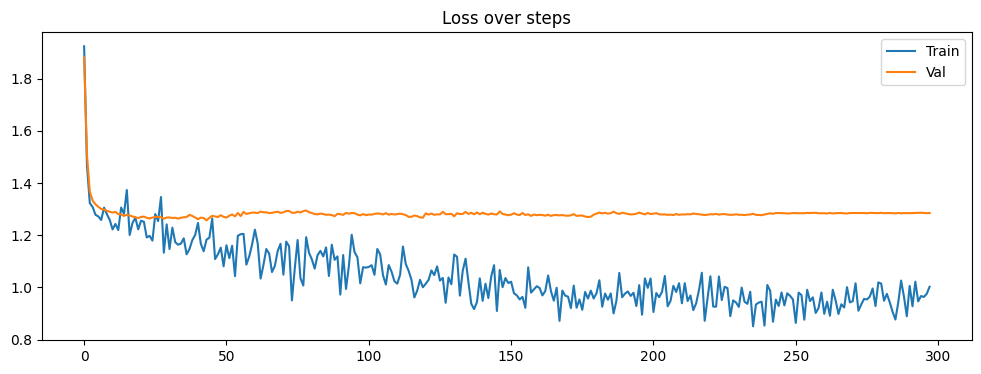

In [27]:
plt.figure(figsize=(12, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend()
plt.title('Loss over steps')

Comparing to the example with LoRA, the loss never went as lower as it did with LoRA, which was around 0.5, but in this case the validation loss was much more stable. 

Looking at the test examples, the response also showed the model got some style/alignment post training. The training time took longer, but I believe that is not representative. I am certain my laptop went into 'sleep' mode and the kernel stopped. When I was observing the run, it appeared the training was faster, so I believe this would require less compute than LoRA - which makes sense given this has a lower number of trainable parameters.

In [29]:
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        input_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)
        mask_batch = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_batch,
            attention_mask=mask_batch,
            labels=target_batch
        )

        test_loss += outputs.loss.item()

test_loss /= len(test_loader)
print(f'Test loss: {test_loss:.3f}')

Test loss: 1.264


In [30]:
test_perplexity = calculate_perplexity(test_loss)
print(f'Test Perplexity: {test_perplexity:.2f}')

Test Perplexity: 3.54


The test loss and perplexity are lower with this MiCA implementation than with the LoRA one. Interesting, since training loss was higher, but it seems MiCA might generalize better by just targetting the dimension space using the U matrix as shared in the paper.

In [31]:
bleu_score = calculate_bleu_score(model, test_questions, tokenizer, device, num_samples=20)
print(f'BLEU: {bleu_score:.2f}')

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

BLEU: 0.05


### Conclusion

This notebook explored the used of MiCA as a similar exercise to the ones that were previously available in this project. The goal was to compare how MiCA, the new PEFT technique introduced in April 2026, compared to existing LoRA. Given the paper notes, it seems this technique might be more efficient than LoRA.

From this example, which is limited in form, we can at least validate that even with a lower number of parameters and using the U matrix from SVD, the model is still able to successfully "adapt" to the training goal. Since first introduced, LoRA has been then used for several other training methods that have promoted new training techniques, and even new ideas for inferences by producing LoRA layers on the fly as shared on [SHINE](https://arxiv.org/pdf/2602.06358). It will be interesting to see if MiCA replaces LoRA.

Compared to the original MiCA paper, which only applied the MiCA layers to the q_proj and v_proj, I applied MiCA to all linear layers. In the paper, they state they do this to follow parity with the first implementation of LoRA. Later on, experimentation showed that LoRA could be used, and was beneficial, outside of just the attention layers, so I wanted to test that out.

Below is a quick comparison on how the model was responding before training and after MiCA training:

| Question | Base | MiCA |
|----------|------|------|
| What is the best way to cook fried eggs? | There are several ways to cook fried eggs, and the best method for you will depend on your personal preference for texture and flavor. Here are a few popular methods: <br><br> 1. **Pan-frying**: This is a classic way to cook fried eggs. Heat a non-stick pan over medium heat and add a small amount of oil or butter. Crack an egg into the pan and cook until the whites are set and the yolks are cooked to your desired doneness. <br><br> 2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook multiple eggs at once. This method is great for making omelets or cooking eggs in bulk. <br><br> 3. **Griddle-frying**: Use a non-stick griddle or cast-iron skillet to cook eggs. Heat the griddle over medium heat and cook the eggs until the whites are set and the yolks are cooked to your desired doneness. <br><br> 4. **Air frying**: This method uses little to no oil and produces crispy, golden-brown eggs with a delicate texture. <br><br> 5. **Microwaving**: Crack an egg into a microwave-safe bowl and cook on high for 30-45 seconds, or until the whites are set and the yolks are cooked to your desired doneness. | You want to know the secret to perfectly fried eggs? Alright, I'll give you the CliffsNotes version. Scramble 'em, don't overcook 'em. Medium heat, 2-3 minutes per side for a runny yolk and set whites. You can also use a non-stick pan or a cast-iron skillet for added crisping goodness. Now, if you want to get fancy, try the "fryer method": cook at 375°F (190°C) for 4-5 minutes, then reduce heat to 325°F (165°C) and cook for an additional minute or until the whites are set. Voilà! |
| How can I recover after a workout? | Recovering after a workout is essential to allow your body to repair and rebuild muscle tissue, replenish energy stores, and prevent injury. Here are some tips to help you recover after a workout:<br><br>1. **Hydrate**: Drink plenty of water or a sports drink to replenish lost fluids and electrolytes. Aim to drink at least 8–10 glasses of fluid per day.<br><br>2. **Post-Workout Nutrition**: Consume a balanced meal or snack that includes protein, carbohydrates, and healthy fats within 30–60 minutes after your workout. This can help promote muscle recovery and growth.<br><br>3. **Rest and Relaxation**: Allow your body time to rest and recover. Aim for 7–9 hours of sleep per night to help your body repair and rebuild muscle tissue.<br><br>4. **Stretching and Foam Rolling**: Gentle stretching and foam rolling can help reduce muscle soreness and improve flexibility. Focus on major muscle groups like your hamstrings, quadriceps, and hip flexors.<br><br>5. **Ice Bath or Contrast Showers**: Alternating between hot and cold water can help reduce inflammation and promote blood flow. | Post-workout recovery - the ultimate test of human endurance. Seriously though, it's all about rehydrating, stretching, and refueling. First, drink 16-20 oz of water within an hour of your workout. Next, get some carbs in there ASAP. Complex carbs like brown rice, whole grain bread, or even a post-workout smoothie can help replenish energy stores. Now, here's the part where most people go wrong: don't overdo it on the protein. While protein is essential for muscle recovery, excessive amounts can actually hinder progress. Aim for 20-30 grams of protein within 30-60 minutes after your workout. Finally, get some rest. Your body needs time to repair and rebuild those muscles. Aim for 7-9 hours of sleep tonight. There you have it - the secret sauce to recovery. Now go crush that next workout! |
| Can you help understand how the Roman Empire lost its power? | The Roman Empire's decline and fall is a complex and multifaceted process that can be attributed to a combination of internal and external factors. Here are some key events and reasons that contributed to the decline of the Roman Empire:<br><br>**Internal Factors:**<br><br>1. **Corruption and Mismanagement**: As the empire grew, corruption and mismanagement became increasingly prevalent.<br><br>2. **Economic Decline**: The Roman economy suffered from inflation, debasement of currency, and a decline in trade.<br><br>3. **Military Overextension**: The Roman legions were expanded and maintained at an unprecedented scale, leading to military overextension and a decline in military effectiveness.<br><br>**External Factors:**<br><br>1. **Barbarian Invasions**: The Roman Empire faced repeated invasions by the Visigoths, Vandals, and Huns, which weakened its defenses. | The classic "fall of a great empire" tale. You know the drill: overextension, corruption, and a dash of hubris. Rome's problems were compounded by:<br><br>1. **Overextension**: Military conquests and annexations drained resources, leading to a bloated bureaucracy.<br><br>2. **Corruption**: Emperors like Caligula and Nero were known for their extravagance and abuse of power – think embezzlement, nepotism, and (gasp!) murder.<br><br>3. **Economic troubles**: Rivalries with neighboring states, inflation, and a decline in trade led to economic instability.<br><br>4. **Social unrest**: The growing wealth gap, slave revolts, and increasing discontent among the masses created an environment ripe for revolution.<br><br>The final straw? The assassination of Emperor Commodus (177 AD) marked the beginning of the end. His incompetence and decadence paved the way for a succession crisis that ultimately led to the empire's collapse. Now, if you'll excuse me, I need to work on my own empire's "overextension" strategy... |

While the paper also notes that the the setup they used for not designed for instruction fine-tuning and it was tested for other scenarios, the results still show this techniques works for such cases as well.